In [1]:
import os
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

### Configuration & Spark session

In [2]:
PROJECT_ROOT = Path(
    r"D:\Fourth Semester\Big Data\Project\Timetable-Based Bus Route Performance Analytics"
).resolve()
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DIR", PROJECT_ROOT / "output"))
EVAL_DIR = OUTPUT_DIR / "eval_predictions"

N_CORES = int(os.environ.get("SPARK_CORES", "8"))

spark = (
    SparkSession.builder
    .appName("BusRoute_06_ModelEvaluation")
    .master(f"local[{N_CORES}]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 3.5.8


In [3]:
comparison_df = pd.read_csv(OUTPUT_DIR / "model_comparison.csv")

with open(OUTPUT_DIR / "cv_results.json") as f:
    cv_results = json.load(f)

with open(OUTPUT_DIR / "feature_importance.json") as f:
    feature_importance = json.load(f)

model_names = comparison_df["Model"].tolist()
label_names = feature_importance["label_names"]
assembler_inputs = feature_importance["assembler_inputs"]

predictions = {}
for name in model_names:
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    path = EVAL_DIR / f"{safe_name}.parquet"
    predictions[name] = spark.read.parquet(str(path)).cache()

print("Models loaded:", model_names)
print("Classes:", label_names)
print()
print(comparison_df.to_string(index=False))

Models loaded: ['Decision Tree', 'Random Forest', 'Logistic Regression (baseline)']
Classes: ['High', 'Low', 'Medium']

                         Model  Training Time (s)  accuracy  weightedPrecision  weightedRecall     f1
                 Decision Tree              614.9    0.9610             0.9616          0.9610 0.9609
                 Random Forest             1463.2    0.8073             0.8125          0.8073 0.8045
Logistic Regression (baseline)              414.0    0.7194             0.7183          0.7194 0.7184


## Core metrics: Accuracy, Precision, Recall, F1

In [4]:
metrics_table = comparison_df[["Model", "accuracy", "weightedPrecision", "weightedRecall", "f1", "Training Time (s)"]]
metrics_table = metrics_table.rename(columns={
    "weightedPrecision": "Precision", "weightedRecall": "Recall", "f1": "F1", "accuracy": "Accuracy"
})
print(metrics_table.to_string(index=False))

                         Model  Accuracy  Precision  Recall     F1  Training Time (s)
                 Decision Tree    0.9610     0.9616  0.9610 0.9609              614.9
                 Random Forest    0.8073     0.8125  0.8073 0.8045             1463.2
Logistic Regression (baseline)    0.7194     0.7183  0.7194 0.7184              414.0


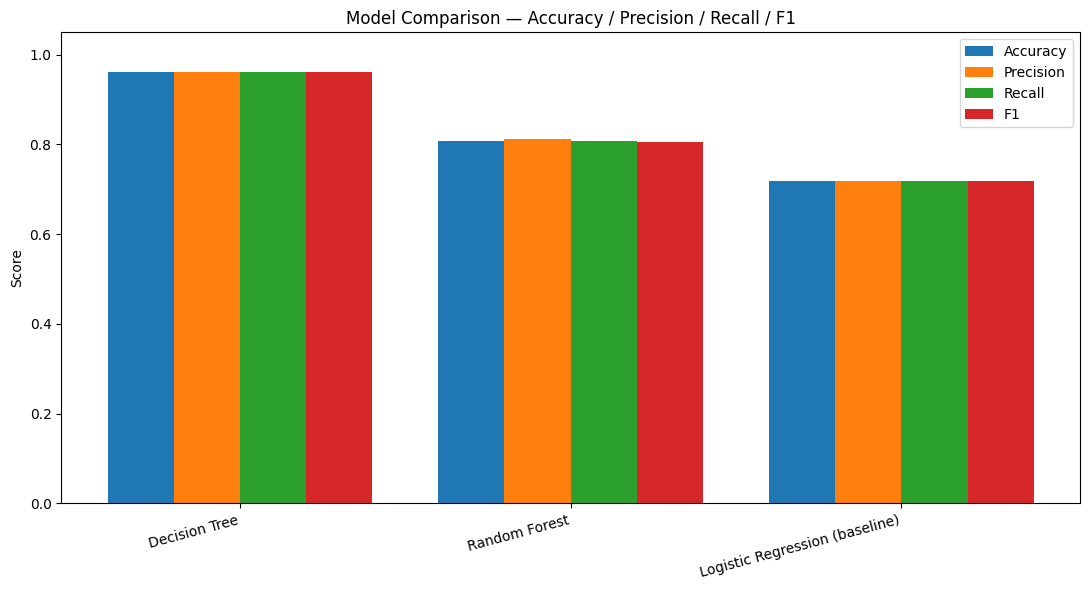

In [5]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics_table))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
for i, metric in enumerate(metric_cols):
    ax.bar(x + i * width, metrics_table[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_table["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy / Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.show()

## Confusion matrices

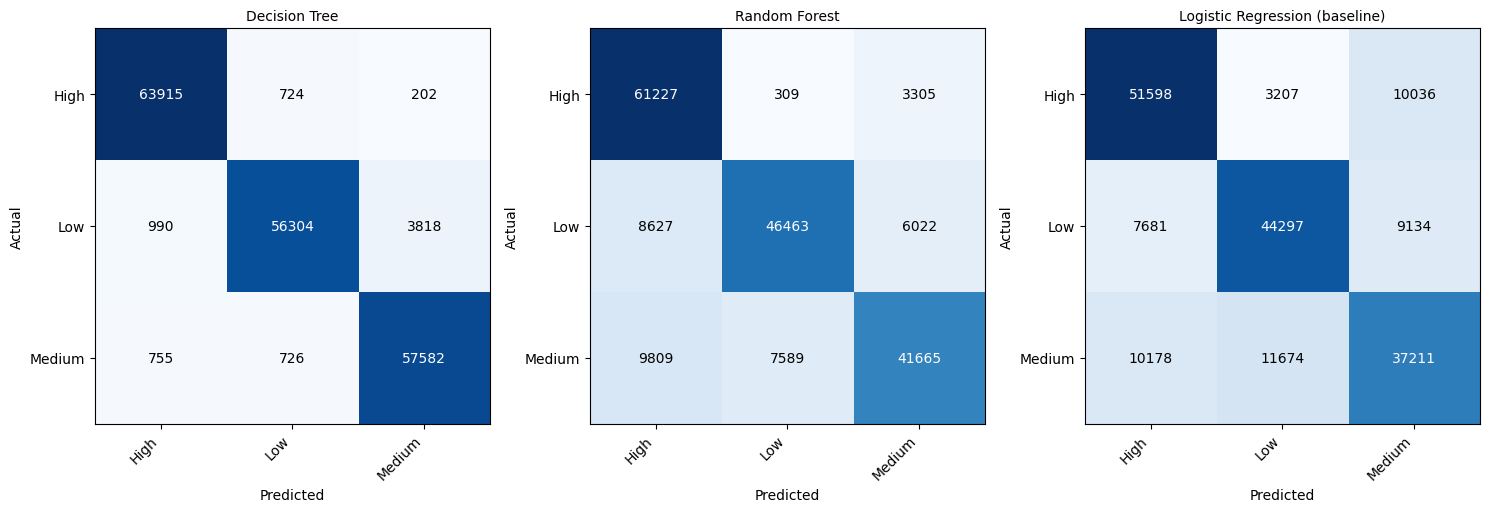

In [6]:
n_classes = len(label_names)

def confusion_matrix_from_spark(preds_df):
    counts = (
        preds_df.groupBy("label", "prediction").count()
        .toPandas()
        .astype({"label": int, "prediction": int})
    )
    matrix = np.zeros((n_classes, n_classes), dtype=int)
    for _, row in counts.iterrows():
        matrix[int(row["label"]), int(row["prediction"])] = row["count"]
    return matrix

confusion_matrices = {name: confusion_matrix_from_spark(df) for name, df in predictions.items()}

fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 5))
for ax, name in zip(axes, model_names):
    cm = confusion_matrices[name]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(n_classes)); ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticks(range(n_classes)); ax.set_yticklabels(label_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

## ROC curves 

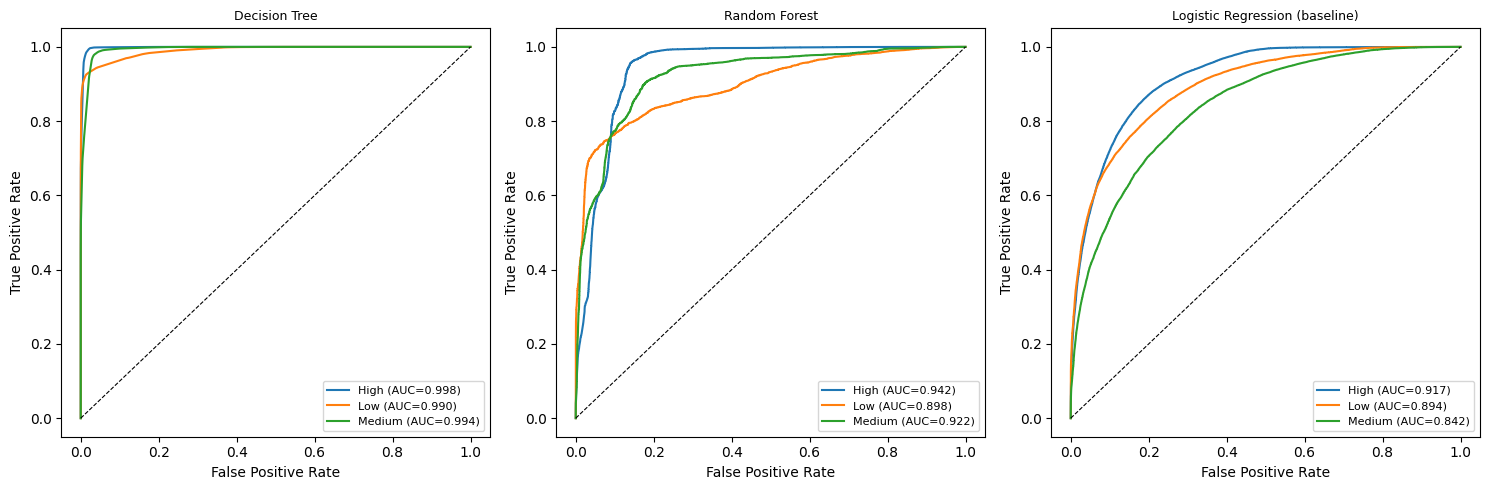

In [7]:
from sklearn.metrics import roc_curve, auc

def get_roc_data(preds_df, has_probability):
    pdf = preds_df.select("label", "prediction", *(["probability_array"] if has_probability else [])).toPandas()
    roc_data = {}
    for class_idx, class_name in enumerate(label_names):
        y_true = (pdf["label"] == class_idx).astype(int)
        if has_probability:
            y_score = pdf["probability_array"].apply(lambda arr: arr[class_idx])
        else:
            # No calibrated probability column on this model: fall back to a
            # 0/1 indicator of whether this class was the predicted one, as
            # a coarse ranking-score proxy.
            y_score = (pdf["prediction"] == class_idx).astype(int)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_data[class_name] = (fpr, tpr, auc(fpr, tpr))
    return roc_data

fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 5))
for ax, name in zip(axes, model_names):
    has_prob = "probability_array" in predictions[name].columns
    roc_data = get_roc_data(predictions[name], has_prob)
    for class_name, (fpr, tpr, roc_auc) in roc_data.items():
        ax.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    title_suffix = "" if has_prob else "\n(approximate -- no calibrated probability)"
    ax.set_title(f"{name}{title_suffix}", fontsize=9)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Feature importance

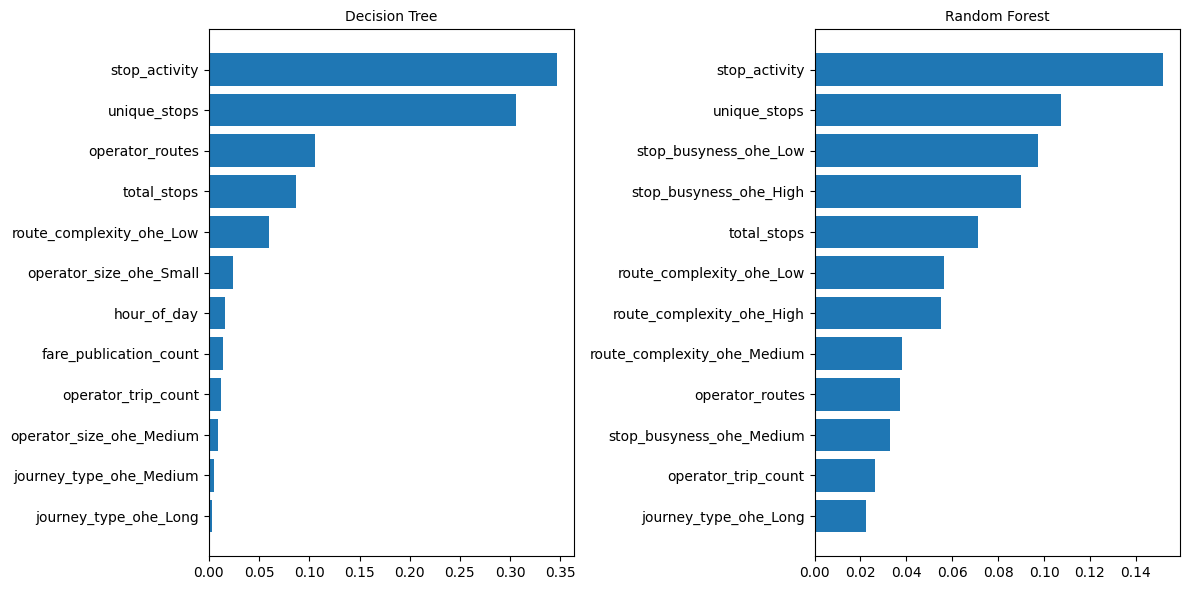

In [16]:
importance_sources = dict(feature_importance["tree_importances"])

fig, axes = plt.subplots(1, len(importance_sources), figsize=(6 * len(importance_sources), 6))
for ax, (name, importances) in zip(axes, importance_sources.items()):
    imp_df = pd.DataFrame({"feature": assembler_inputs, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=True).tail(12)
    ax.barh(imp_df["feature"], imp_df["importance"])
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

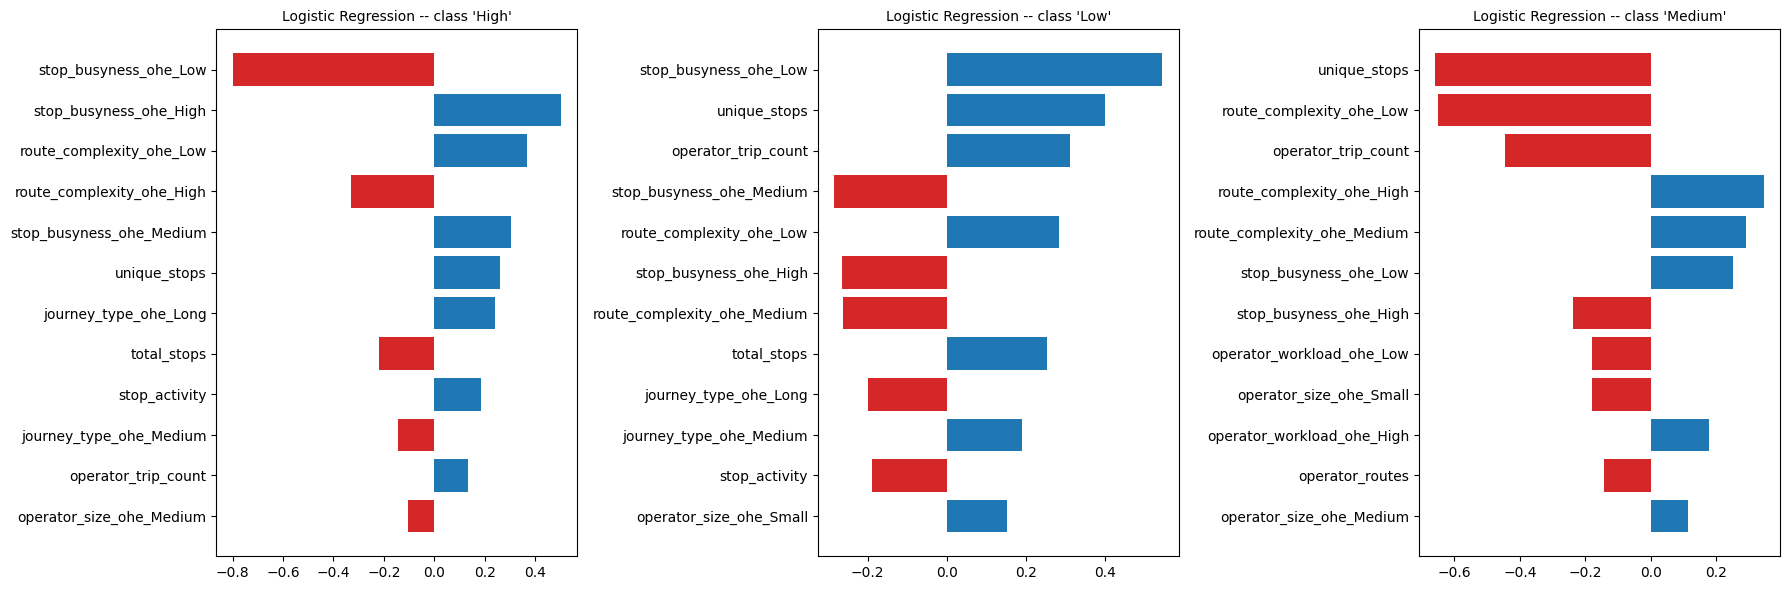

In [9]:
lr_coef = feature_importance["lr_coefficients"]

fig, axes = plt.subplots(1, len(label_names), figsize=(6 * len(label_names), 6))
for ax, class_name in zip(axes, label_names):
    coef_df = pd.DataFrame({"feature": assembler_inputs, "coefficient": lr_coef[class_name]})
    coef_df["abs_coef"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=True).tail(12)
    colors = ["tab:red" if c < 0 else "tab:blue" for c in coef_df["coefficient"]]
    ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
    ax.set_title(f"Logistic Regression -- class '{class_name}'", fontsize=10)
plt.tight_layout()
plt.show()

## Cross-validation results

In [10]:
cv_df = pd.DataFrame(cv_results)
cv_df["params_str"] = cv_df["params"].apply(lambda d: ", ".join(f"{k}={v}" for k, v in d.items()))

for name in model_names:
    sub = cv_df[cv_df["model"] == name].sort_values("avg_f1", ascending=False)
    print(f"\n--- {name} ---")
    print(sub[["params_str", "avg_f1"]].to_string(index=False))


--- Decision Tree ---
                   params_str   avg_f1
maxDepth=10, impurity=entropy 0.960423
   maxDepth=10, impurity=gini 0.952896
    maxDepth=5, impurity=gini 0.776780
 maxDepth=5, impurity=entropy 0.775788

--- Random Forest ---
               params_str   avg_f1
 numTrees=50, maxDepth=10 0.794898
numTrees=100, maxDepth=10 0.788490
  numTrees=50, maxDepth=5 0.668728
 numTrees=100, maxDepth=5 0.659661

--- Logistic Regression (baseline) ---
                        params_str   avg_f1
regParam=0.01, elasticNetParam=0.0 0.717541
 regParam=0.1, elasticNetParam=0.0 0.698451
regParam=0.01, elasticNetParam=0.5 0.655737
 regParam=0.1, elasticNetParam=0.5 0.618685


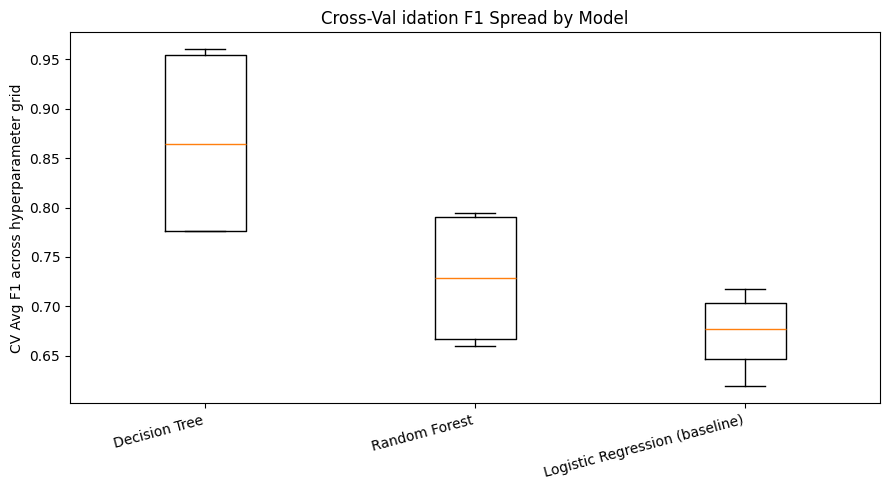

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
data = [cv_df[cv_df["model"] == name]["avg_f1"].values for name in model_names]
ax.boxplot(data, tick_labels=model_names)
ax.set_ylabel("CV Avg F1 across hyperparameter grid")
ax.set_title("Cross-Val idation F1 Spread by Model")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Training time and scalability

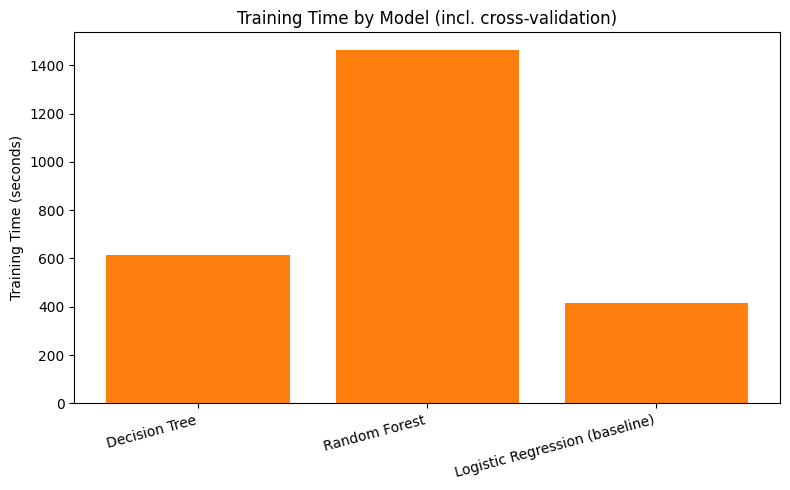

Random Forest takes longer to train but may achieve better F1.


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(comparison_df["Model"], comparison_df["Training Time (s)"], color="tab:orange")
ax.set_ylabel("Training Time (seconds)")
ax.set_title("Training Time by Model (incl. cross-validation)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print(
    "Random Forest takes longer to train but may achieve better F1."
)

## Final comparison table and recommendation

In [13]:
final_table = comparison_df.sort_values("f1", ascending=False).reset_index(drop=True)
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(final_table.to_string(index=False))

best_name = final_table.iloc[0]["Model"]
baseline_f1 = final_table[final_table["Model"] == "Logistic Regression (baseline)"]["f1"].iloc[0]
best_f1 = final_table.iloc[0]["f1"]

print(f"\nBest model      : {best_name}")
print(f"Baseline (LR) F1: {baseline_f1:.4f}")
print(f"Best model F1   : {best_f1:.4f}")
print(f"Uplift          : {best_f1 - baseline_f1:+.4f}")

FINAL MODEL COMPARISON
                         Model  Training Time (s)  accuracy  weightedPrecision  weightedRecall     f1
                 Decision Tree              614.9    0.9610             0.9616          0.9610 0.9609
                 Random Forest             1463.2    0.8073             0.8125          0.8073 0.8045
Logistic Regression (baseline)              414.0    0.7194             0.7183          0.7194 0.7184

Best model      : Decision Tree
Baseline (LR) F1: 0.7184
Best model F1   : 0.9609
Uplift          : +0.2425


In [20]:
import os

print(os.listdir(OUTPUT_DIR))

['best_model', 'checkpoint', 'cv_results.json', 'eval_predictions', 'feature_importance.json', 'feature_metadata.json', 'final_feature_dataset.csv', 'final_feature_dataset.parquet', 'final_schedule.csv', 'final_schedule.parquet', 'model_comparison.csv', 'schedule_checkpoint', 'unseen_records_sample.parquet']


In [19]:
spark.stop()
print("Spark session stopped. Notebook 06 complete.")

Spark session stopped. Notebook 06 complete.
